# When analysts *can't agree*, does the stock do worse? 🗣️
### The Diether-Malloy-Scherbina puzzle — a real academic effect that *doesn't* survive free data, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Does_dispersion_lose%3F: Mixed](https://img.shields.io/badge/Does_dispersion_lose%3F-Mixed-8b949e?style=flat-square)

Here's a genuinely counter-intuitive idea from finance research. When Wall Street analysts **wildly disagree** about a company's earnings — one says it'll make \$8 a share, another says \$16 — your gut says *"risky, so it should pay more."* But a famous 2002 study (Diether, Malloy & Scherbina) found the **opposite**: the stocks analysts argue about most go on to earn **lower** returns. They called it a *puzzle*.

The reason (an even older idea, Miller 1977): when it's hard to **short** a stock, the price ends up reflecting only the **optimists** — the pessimists are sidelined. Lots of disagreement then means the price is too **high**, and it drifts back down. Disagreement = over-pricing = future under-performance.

It's a real, published effect. So we tried to see it ourselves — and ran straight into a wall that's worth understanding: **free data only tells you what analysts think *today*, not what they thought every month for 20 years.** That one limitation changes everything.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo tests and the honest data autopsy? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** We use a fixed **40-name large-cap basket** (names still trading today). That carries **survivorship** — and, crucially, yfinance gives only a **single current snapshot** of analyst disagreement, not a history. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from analyst_dispersion import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    DISP, PRICES = data.load_real()
    FR = data.trailing_returns(PRICES, DISP)        # dispersion + trailing ret_<H> columns
else:
    DISP = PRICES = FR = None
print("real dispersion cache present:", HAVE_REAL,
      "| names:", (0 if DISP is None else len(DISP)))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_names': 40, 'fp_disp': '272030376053', 'fp_px': '8691afedbd40', 'px_start': '2015-01-02', 'px_end': '2026-06-26', 'n_days': 2887, 'h1': ('1-mo', 40, 3.37, -7.09, 10.46, 74, 3.21, 0.003, -0.435), 'h3': ('3-mo', 40, 12.52, 20.19, -7.67, 59, -0.39, 0.633, -0.12), 'h6': ('6-mo', 40, 8.06, 26.32, -18.26, 48, -0.82, 0.341, -0.108), 'h12': ('12-mo', 40, 16.35, 56.11, -39.76, 41, -0.99, 0.237, 0.105), 'tercile12': [16.35, 35.89, 56.11], 'net': [('1-mo', 10.46, 9.98), ('3-mo', -7.67, -8.32), ('6-mo', -18.26, -19.16), ('12-mo', -39.76, -41.16)], 'robust': [(2, -30.15, -1.08, 0.288), (3, -39.76, -0.99, 0.237), (5, -53.62, -0.85, 0.229)], 'syn': [(0.0, -0.47, 0.167, 0), (0.7, 65.3, 2.629, 100)], 'low_disp': [('CSCO', 0.019), ('KO', 0.021), ('PG', 0.028), ('JNJ', 0.032)], 'high_disp': [('MRK', 0.818), ('TSLA', 0.891), ('ORCL', 1.066), ('BA', 7.168)]}


real dispersion cache present: True | names: 40


## The answer first

| Question | Answer |
|---|---|
| Do high-disagreement stocks earn less? | **Only over the *last month* — and even then we can't trust it.** Sort by disagreement and the calm-consensus names beat the argued-over ones by **+10%** over the trailing month. But that's **one snapshot on one day**, not a repeatable result. |
| Does it hold over longer windows? | **No — it flips hard.** Over the trailing *year*, the high-disagreement names **crushed** the calm ones (**+56% vs +16%**). The puzzle runs backwards here. |
| Why the reversal? | **Survivorship.** The argued-over names that *survived* to 2026 are the giant winners — NVDA, TSLA, ORCL. Their failed lookalikes are gone from the data, so the "disagreement loses" leg is stacked with champions. |
| Can I trade it? | **No.** We only know *today's* disagreement, so we can only line it up against the *past* — that's a coincidence, not a strategy you could have run. |

> The textbook effect is **real in the research**. On free, survivor-tilted, single-snapshot data it shows up for one month and then face-plants. An honest *Weak*.

## 1 · The claim

> *"When analysts disagree a lot about a company's earnings, the stock is probably **over-priced** — because only the optimists' view is in the price (you can't easily bet against it). So the high-disagreement names quietly **under-perform** as reality sets in. Buy the boring consensus names, avoid (or short) the controversial ones."*

This is **Diether, Malloy & Scherbina (2002)** in the *Journal of Finance* — a real, much-cited result, built on the older **Miller (1977)** over-pricing idea. It's a *puzzle* because it's the opposite of "more uncertainty → more reward." The question for us isn't "did they make it up?" — it's: **can a free-data desk even see it?**

## 2 · So what?

If disagreement really predicts under-performance, you'd have a clean, fundamental signal: just buy the names everyone agrees on. But two traps sit in the way. **(1) Survivorship:** a basket of today's survivors is missing every controversial company that blew up — so the "disagreement" leg is biased toward winners. **(2) No history:** free data gives a *snapshot* of disagreement, not a 20-year monthly panel, so we literally cannot run the forward test the academics ran. We'll show exactly how both traps bend the result.

## 3 · How would we even know?

We take a fixed **40-name large-cap basket** and, for each name, pull analysts' **earnings estimates** — the *low*, the *mean*, and the *high* guess for this year's EPS. The **disagreement** score is simply how far apart the high and low are, scaled by the average:

$$\text{dispersion} = \frac{\text{high estimate} - \text{low estimate}}{|\text{mean estimate}|}.$$

Tight estimates (everyone agrees) → small number; wild spread (big argument) → large number. Then we **sort** the basket into three groups by disagreement and compare their returns. The catch we keep flagging: we only know *today's* disagreement, so we compare it to each name's **trailing** return (the move *into* today) — a coincidence check, not a forward trade.

## 4 · The teardown — let's actually look

**First, who do analysts actually argue about?** Here are the calmest-consensus and most-argued-over names in the basket. It passes the smell test: steady staples (Coke, P&G, J&J) at the calm end; cyclicals and high-fliers (Tesla, Oracle, Boeing) at the loud end.

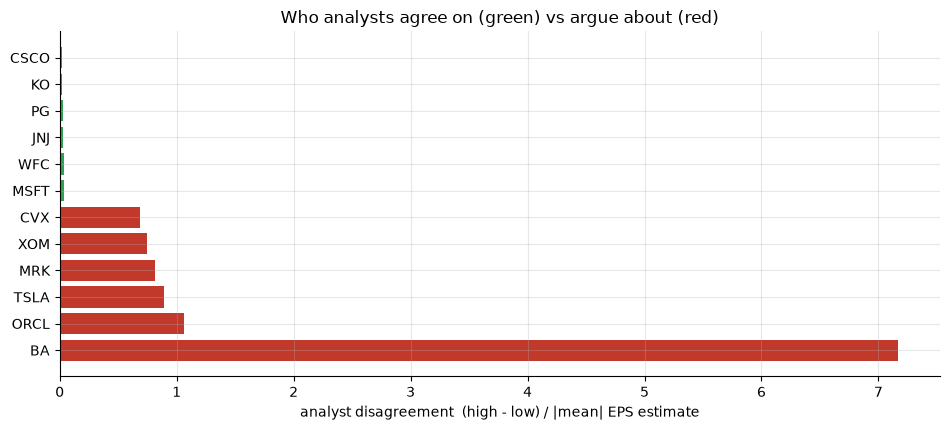

calmest: CSCO 0.019   loudest: BA 7.168


In [2]:
if HAVE_REAL:
    ds = DISP.sort_values('dispersion')
    lows = list(zip(ds['ticker'][:6], ds['dispersion'][:6]))
    highs = list(zip(ds['ticker'][-6:], ds['dispersion'][-6:]))
else:
    lows = R['low_disp']; highs = R['high_disp']
names = [t for t,_ in lows] + [t for t,_ in highs]
vals  = [v for _,v in lows] + [v for _,v in highs]
cols  = [GREEN]*len(lows) + [RED]*len(highs)
fig, ax = plt.subplots(figsize=(9.6, 4.4))
ax.barh(range(len(names)), vals, color=cols)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
ax.set_xlabel('analyst disagreement  (high - low) / |mean| EPS estimate')
ax.set_title('Who analysts agree on (green) vs argue about (red)')
ax.invert_yaxis(); plt.tight_layout(); plt.show()
print('calmest:', names[0], f'{vals[0]:.3f}', '  loudest:', names[-1], f'{vals[-1]:.3f}')

The sort is sensible — so the *measure* is doing its job. Now the real question: do the calm names (green) actually out-earn the loud ones (red), as the puzzle predicts?

**The disagreement-vs-return test, at four windows.** We go *long the calm tercile, short the loud tercile* (the DMS bet) and read the spread over the trailing 1, 3, 6, and 12 months. If the puzzle holds, every bar should be **positive** (calm beats loud).

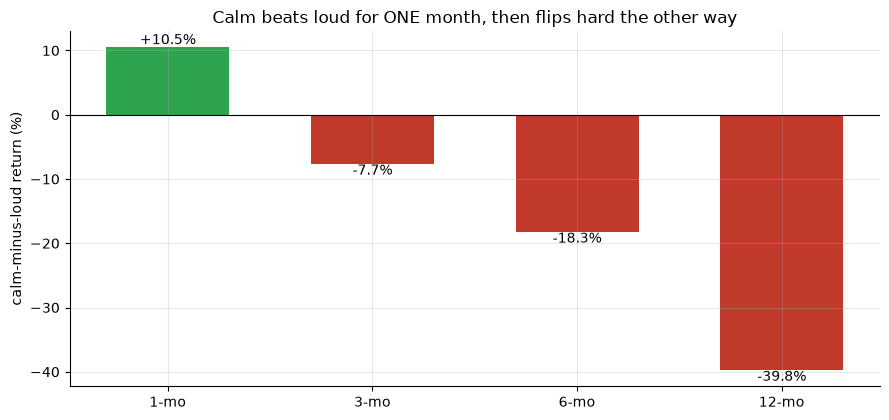

calm-minus-loud by window: {'1-mo': 10.5, '3-mo': -7.7, '6-mo': -18.3, '12-mo': -39.8}


In [3]:
labels = ['1-mo','3-mo','6-mo','12-mo']
if HAVE_REAL:
    ls = [st.summarize(FR, c, placebo=False)['ls_mean']*100 for c in ['ret_21', 'ret_63', 'ret_126', 'ret_252']]
else:
    ls = [R['h1'][4], R['h3'][4], R['h6'][4], R['h12'][4]]
cols = [GREEN if v>0 else RED for v in ls]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(labels, ls, color=cols, width=.6)
for i,v in enumerate(ls): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom' if v>0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('calm-minus-loud return (%)')
ax.set_title('Calm beats loud for ONE month, then flips hard the other way')
plt.tight_layout(); plt.show()
print('calm-minus-loud by window:', {l: round(v,1) for l,v in zip(labels, ls)})

There's the whole story in one chart. At **1 month** the puzzle looks alive — calm beats loud by **+10.5%**. But at **3, 6, and 12 months the bar goes red**: the loud, argued-over names *out-earned* the calm ones, by a stunning **40 percentage points** over the year. The longer you look, the more backwards the puzzle runs.

**Why?** Look at the 12-month returns by disagreement group. If the puzzle held, this should slope *down* (more disagreement → lower return). It slopes firmly **up**.

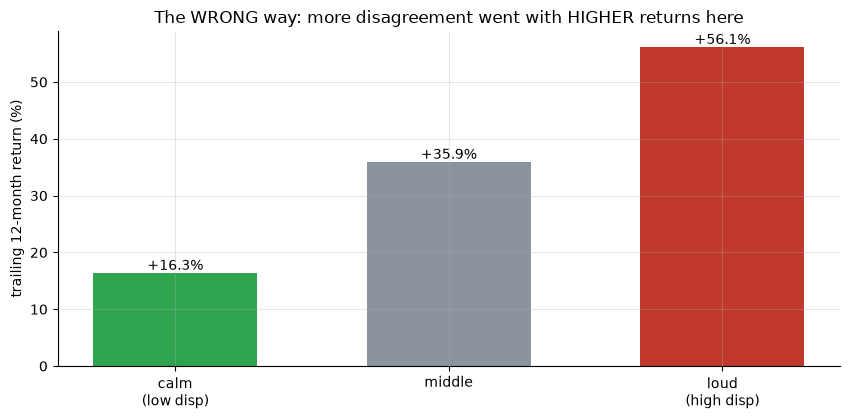

12-mo return by group (calm->loud): [16.3, 35.9, 56.1]


In [4]:
if HAVE_REAL:
    terc = st.bucket_means(FR, 'ret_252')*100
else:
    terc = np.array(R['tercile12'])
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(['calm\n(low disp)','middle','loud\n(high disp)'], terc, color=[GREEN,GREY,RED], width=.6)
for i,v in enumerate(terc): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('trailing 12-month return (%)')
ax.set_title('The WRONG way: more disagreement went with HIGHER returns here')
plt.tight_layout(); plt.show()
print('12-mo return by group (calm->loud):', [round(float(v),1) for v in terc])

The loud group returned **+56%** over the year; the calm group only **+16%**. That's the *opposite* of the puzzle — and it's the **survivorship trap** made visible. The argued-over names that *survived* to 2026 (NVDA, Tesla, Oracle) are exactly the ones whose big, controversial bets paid off. Their failed twins aren't in the data.

## 5 · The verdict

- **Signal — Weak.** Calm-beats-loud shows up at **one** window (1-month, **+10.5%**) and **reverses** at every other. One snapshot isn't proof.
- **Tradability — Mirage.** We only know *today's* disagreement, so there's no forward trade — just a coincidence with the past.
- **"Does disagreement lose?" — Mixed.** Real in the research; here it's true for a month and backwards over a year, swamped by survivorship.

## 6 · Could you actually trade it? — no, and here's the honest reason

Suppose we *pretend* the trailing sort were a real trade and charge it normal costs. The 1-month "+10%" barely dents to "+10%" net. So is it tradable? **No** — and this is the key lesson, not a cost story.

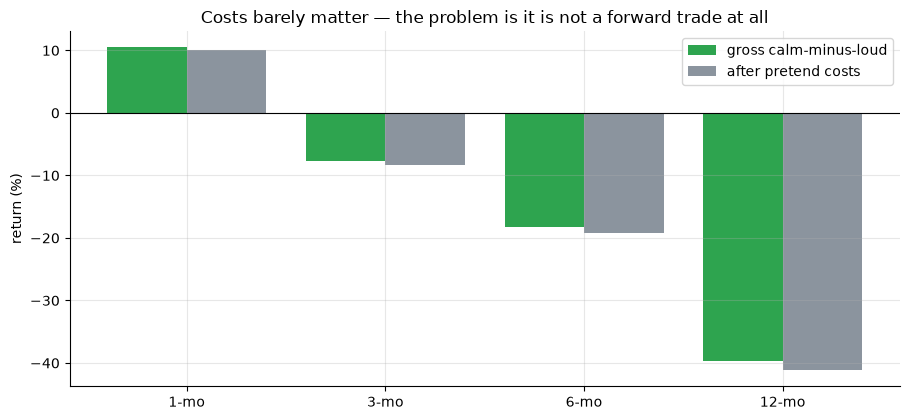

1-mo gross/net: 10.5 10.0


In [5]:
labels = ['1-mo','3-mo','6-mo','12-mo']
if HAVE_REAL:
    g, nv = [], []
    for c,h in zip(['ret_21', 'ret_63', 'ret_126', 'ret_252'], [21,63,126,252]):
        cc = st.net_of_costs(FR, c, horizon_days=h)
        g.append(cc['gross']*100); nv.append(cc['net']*100)
else:
    g = [n[1] for n in R['net']]; nv = [n[2] for n in R['net']]
x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, g, .4, color=GREEN, label='gross calm-minus-loud')
ax.bar(x+.2, nv, .4, color=GREY, label='after pretend costs')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('return (%)'); ax.set_title('Costs barely matter — the problem is it is not a forward trade at all')
ax.legend(); plt.tight_layout(); plt.show()
print('1-mo gross/net:', round(g[0],1), round(nv[0],1))

> The "+10% net" is **bookkeeping on returns that already happened** — you'd have needed to know today's disagreement a month ago to capture it, and you didn't. That's why the tradability stamp is **Mirage**, full stop: there is no version of this you could have run.

## 7 · Going further 🚪

- **The history is the whole game.** With a real **I/B/E/S dispersion panel** (monthly, 20+ years), you could run the *forward* test DMS ran. Free data simply doesn't carry it — and that gap is the entire reason we land *Weak/Mirage* instead of confirming a real academic result.
- **Survivorship cuts the wrong way.** Here the surviving loud names are winners, so the bias *hides* the effect. Add delisted controversial names and the picture could change.
- **Where it's strongest.** Later work (Avramov et al. 2009) ties the effect to **distressed, low-rated** names — not the liquid large-caps we used. Wrong pond for a big fish.

*Think you can see the puzzle on free data? Show a calm-minus-loud spread that's positive and significant on a real **forward** sort across multiple windows — then we'll talk.*